In [7]:
# импорт нужных библиотек
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import cross_val_score
from sklearn import metrics
from collections import Counter

In [8]:
def Reg_Models_Evaluation_Metrics(model, X_train, y_train, X_test, y_test, y_pred):
    cv_score = cross_val_score(estimator=model, X=X_train, y=y_train, cv=10)

    r2 = model.score(X_test, y_test)
    n = X_test.shape[0]
    p = X_test.shape[1]
    adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    RMSE = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
    R2 = model.score(X_test, y_test)
    CV_R2 = cv_score.mean()

    print(f'RMSE:  {round(RMSE, 4)}\n R2: {round(R2, 4)}\n Adjusted R2: {round(adjusted_r2, 4)}\n Cross Validated R2: {round(cv_score.mean(), 4)}')
    return R2, adjusted_r2, CV_R2, RMSE

# Загрузка данных

Датасет содержит статистику героев Dota 2 из профессиональных матчей.

**Целевая переменная**:  — процент побед героя (задача регрессии).

**Признаки (фичи)**:
-  — дальность атаки
-  — количество побед в про-матчах
-  — количество пиков
-  — количество банов
-  → закодируем (Melee=0, Ranged=1)
-  → закодируем (all=0, str=1, agi=2, int=3)
-  → закодируем (False=0, True=1)

In [9]:
# загружаем датасет
df = pd.read_csv('/content/dota2HeroPick.csv', index_col=0)

# кодируем категориальные признаки
df['Attack Type Enc'] = df['Attack Type'].map({'Melee': 0, 'Ranged': 1})
df['Primary Attr Enc'] = df['Primary Attribute'].map({'all': 0, 'str': 1, 'agi': 2, 'int': 3})
df['Niche Hero Enc'] = df['Niche Hero?'].astype(int)

df.head(10)

,Name,Primary Attribute,Attack Type,Attack Range,Roles,Total Pro wins,Times Picked,Times Banned,Win Rate,Niche Hero?,Attack Type Enc,Primary Attr Enc,Niche Hero Enc
0,Abaddon,all,Melee,150,"Support, Carry, Durable",8,24,61,33.33,False,0,0,0
1,Alchemist,str,Melee,150,"Carry, Support, Durable, Disabler, Initiator, ...",23,55,22,41.82,False,0,1,0
2,Ancient Apparition,int,Ranged,675,"Support, Disabler, Nuker",40,77,73,51.95,False,1,3,0
3,Anti-Mage,agi,Melee,150,"Carry, Escape, Nuker",40,66,78,60.61,False,0,2,0
4,Arc Warden,agi,Ranged,625,"Carry, Escape, Nuker",5,14,31,35.71,False,1,2,0
5,Axe,str,Melee,150,"Initiator, Durable, Disabler, Carry",122,262,222,46.56,False,0,1,0
6,Bane,all,Ranged,400,"Support, Disabler, Nuker, Durable",84,152,104,55.26,True,1,0,1
7,Batrider,all,Ranged,400,"Initiator, Disabler, Escape",19,54,105,35.19,False,1,0,0
8,Beastmaster,all,Melee,150,"Initiator, Disabler, Durable, Nuker",170,333,484,51.05,False,0,0,0
9,Bloodseeker,agi,Melee,150,"Carry, Disabler, Nuker, Initiator",70,157,461,44.59,False,0,2,0


# Анализ данных

In [10]:
df.shape

(124, 13)

In [11]:
df.describe()

,Attack Range,Total Pro wins,Times Picked,Times Banned,Win Rate,Attack Type Enc,Primary Attr Enc,Niche Hero Enc
count,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000
mean,350.604839,91.975806,183.951613,255.112903,49.390726,0.516129,1.475806,0.161290
std,200.271759,73.328691,143.145492,241.567349,6.317535,0.501767,1.122307,0.369291
min,150.000000,4.000000,5.000000,18.000000,32.730000,0.000000,0.000000,0.000000
25%,150.000000,40.750000,82.500000,80.000000,46.217500,0.000000,0.000000,0.000000
50%,340.000000,79.000000,156.000000,185.500000,50.250000,1.000000,1.000000,0.000000
75%,550.000000,106.000000,215.250000,325.000000,52.492500,1.000000,2.000000,0.000000
max,700.000000,407.000000,801.000000,1049.000000,80.000000,1.000000,3.000000,1.000000


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 124 entries, 0 to 123
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               124 non-null    object 
 1   Primary Attribute  124 non-null    object 
 2   Attack Type        124 non-null    object 
 3   Attack Range       124 non-null    int64  
 4   Roles              124 non-null    object 
 5   Total Pro wins     124 non-null    int64  
 6   Times Picked       124 non-null    int64  
 7   Times Banned       124 non-null    int64  
 8   Win Rate           124 non-null    float64
 9   Niche Hero?        124 non-null    bool   
 10  Attack Type Enc    124 non-null    int64  
 11  Primary Attr Enc   124 non-null    int64  
 12  Niche Hero Enc     124 non-null    int64  
dtypes: bool(1), float64(1), int64(7), object(4)
memory usage: 12.7+ KB


# Визуализация данных

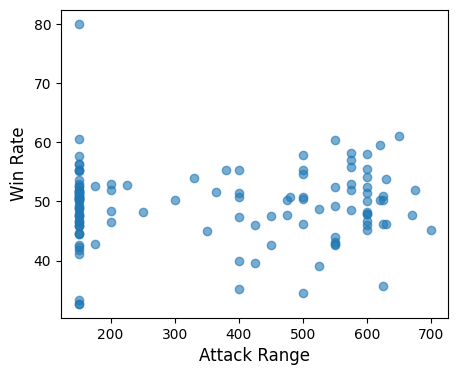

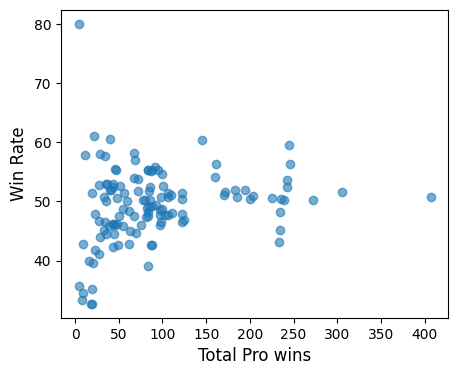

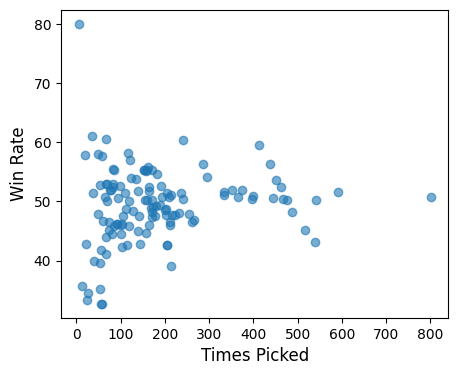

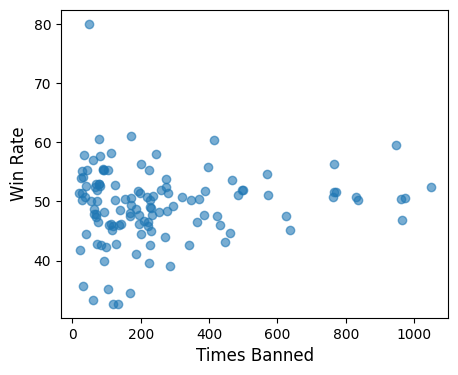

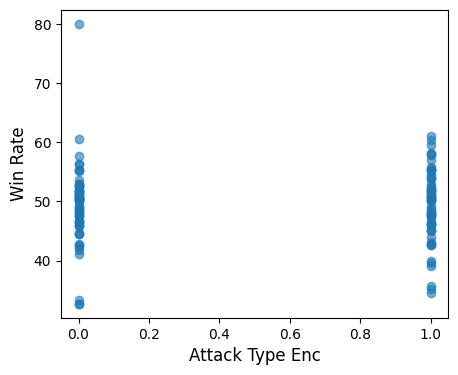

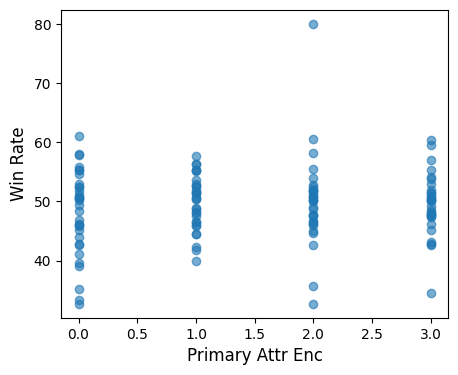

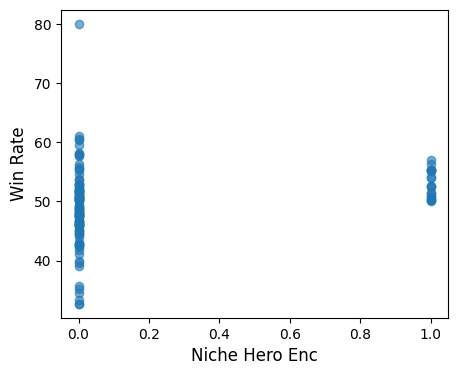

In [13]:
# диаграммы рассеяния: каждый признак vs Win Rate

feature_cols = ['Attack Range', 'Total Pro wins', 'Times Picked', 'Times Banned',
                'Attack Type Enc', 'Primary Attr Enc', 'Niche Hero Enc']

for feature in feature_cols:
    plt.figure(figsize=(5, 4))
    plt.scatter(df[feature], df['Win Rate'], alpha=0.6)
    plt.ylabel('Win Rate', size=12)
    plt.xlabel(feature, size=12)
    plt.show()

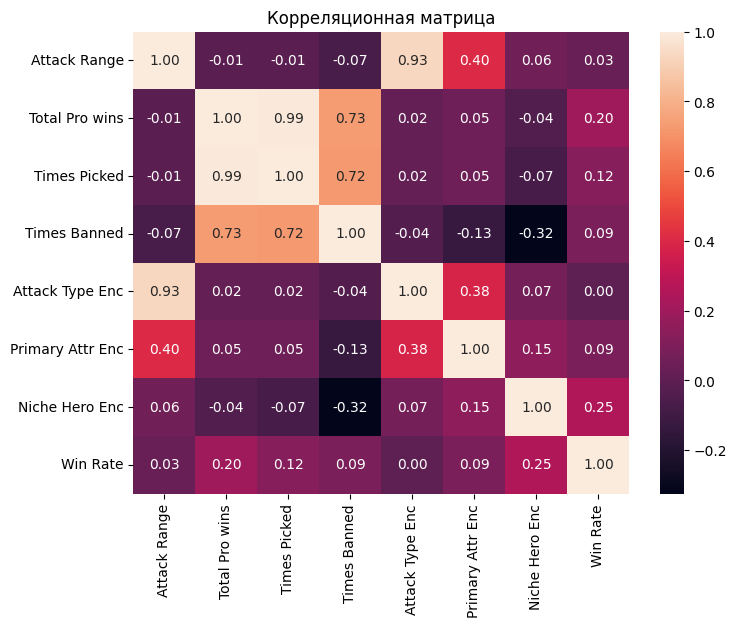

In [14]:
# тепловая карта корреляций числовых признаков

plt.figure(figsize=(8, 6))
sns.heatmap(df[feature_cols + ['Win Rate']].corr(), annot=True, fmt='.2f')
plt.title('Корреляционная матрица')
plt.show()

# Построение модели

## Разделение датасета

**Y** — целевая переменная .  
**X** — числовые и закодированные признаки.

In [15]:
X = df[feature_cols]
y = df['Win Rate']
print(f'X shape: {X.shape} | y shape: {y.shape}')

X shape: (124, 7) | y shape: (124,)


In [16]:
# делим датасет на трейн и тест (80/20)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=15)

## Линейная регрессия

In [17]:
from sklearn.linear_model import LinearRegression

modelLR = LinearRegression()
modelLR.fit(X_train, y_train)
y_pr_LR = modelLR.predict(X_test)

_ = Reg_Models_Evaluation_Metrics(modelLR, X_train, y_train, X_test, y_test, y_pr_LR)

RMSE:  7.4074
 R2: 0.1851
 Adjusted R2: -0.1505
 Cross Validated R2: 0.279


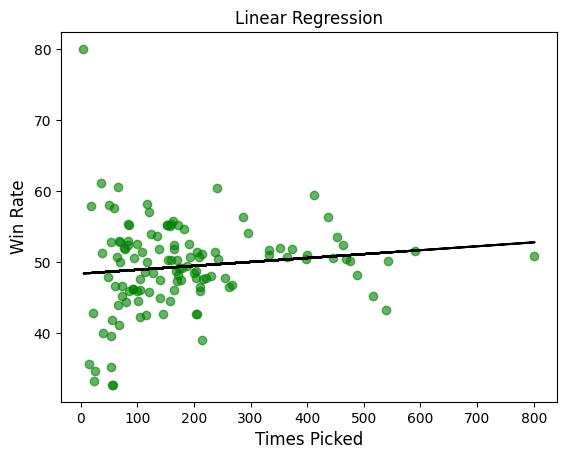

In [18]:
# визуализация линейной регрессии по наиболее коррелирующему признаку — Times Picked

X2 = df['Times Picked'].values[:, np.newaxis]
y2 = df['Win Rate'].values

model2 = LinearRegression()
model2.fit(X2, y2)

plt.scatter(X2, y2, color='g', alpha=0.6)
plt.plot(X2, model2.predict(X2), color='k')
plt.ylabel('Win Rate', size=12)
plt.xlabel('Times Picked', size=12)
plt.title('Linear Regression')
plt.show()

## Полиномиальная регрессия

In [19]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
poly_features = poly.fit_transform(X)

X_p_train, X_p_test, y_p_train, y_p_test = train_test_split(poly_features, y, test_size=0.3, random_state=42)

modelPR = LinearRegression()
modelPR.fit(X_p_train, y_p_train)
y_pr_PR = modelPR.predict(X_p_test)

_ = Reg_Models_Evaluation_Metrics(modelPR, X_p_train, y_p_train, X_p_test, y_p_test, y_pr_PR)

RMSE:  5.074
 R2: -0.0168
 Adjusted R2: -17.8113
 Cross Validated R2: 0.107


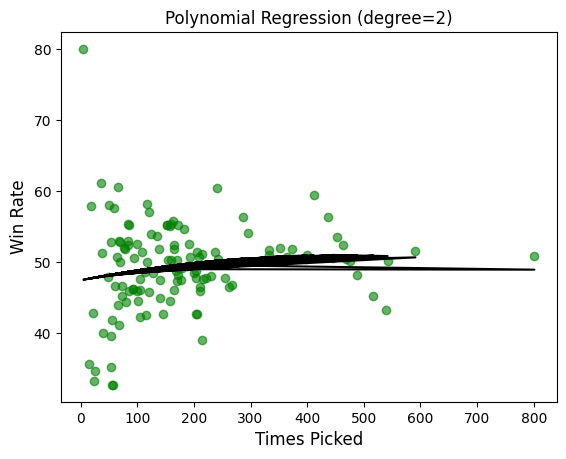

In [20]:
# визуализация полиномиальной регрессии по Times Picked

X2 = df['Times Picked'].values[:, np.newaxis]
y2 = df['Win Rate'].values

poly_features2 = poly.fit_transform(X2)
model2 = LinearRegression()
model2.fit(poly_features2, y2)

plt.scatter(X2, y2, color='g', alpha=0.6)
plt.plot(X2, model2.predict(poly.fit_transform(X2)), color='k')
plt.ylabel('Win Rate', size=12)
plt.xlabel('Times Picked', size=12)
plt.title('Polynomial Regression (degree=2)')
plt.show()

## Decision Tree Regressor

In [21]:
from sklearn.tree import DecisionTreeRegressor

modelDT = DecisionTreeRegressor()
modelDT.fit(X_train, y_train)
y_dt_pred = modelDT.predict(X_test)

_ = Reg_Models_Evaluation_Metrics(modelDT, X_train, y_train, X_test, y_test, y_dt_pred)

RMSE:  10.6593
 R2: -0.6875
 Adjusted R2: -1.3823
 Cross Validated R2: -0.64


## Random Forest Regressor

In [22]:
from sklearn.ensemble import RandomForestRegressor

modelRF = RandomForestRegressor(n_estimators=50)
modelRF.fit(X_train, y_train)
y_rf_pred = modelRF.predict(X_test)

_ = Reg_Models_Evaluation_Metrics(modelRF, X_train, y_train, X_test, y_test, y_rf_pred)

RMSE:  9.3672
 R2: -0.3032
 Adjusted R2: -0.8398
 Cross Validated R2: -0.0784


## SVR — Support Vector Regression

RMSE:  8.1707
 R2: 0.0085
 Adjusted R2: -0.3998
 Cross Validated R2: -0.1091


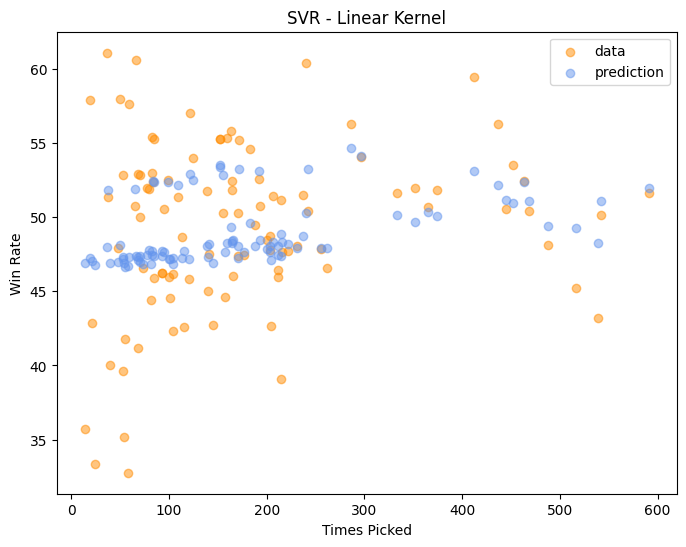

In [23]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Linear kernel
modelSVR = SVR(kernel='linear', cache_size=1000)
modelSVR.fit(X_train_scaled, y_train)
y_svr_pred = modelSVR.predict(X_test_scaled)
_ = Reg_Models_Evaluation_Metrics(modelSVR, X_train_scaled, y_train, X_test_scaled, y_test, y_svr_pred)

plt.figure(figsize=(8, 6))
plt.scatter(X_train['Times Picked'], y_train, color='darkorange', label='data', alpha=0.5)
plt.scatter(X_train['Times Picked'], modelSVR.predict(X_train_scaled), color='cornflowerblue', label='prediction', alpha=0.5)
plt.xlabel('Times Picked')
plt.ylabel('Win Rate')
plt.legend()
plt.title('SVR - Linear Kernel')
plt.show()

RMSE:  8.1181
 R2: 0.0212
 Adjusted R2: -0.3818
 Cross Validated R2: -0.3385


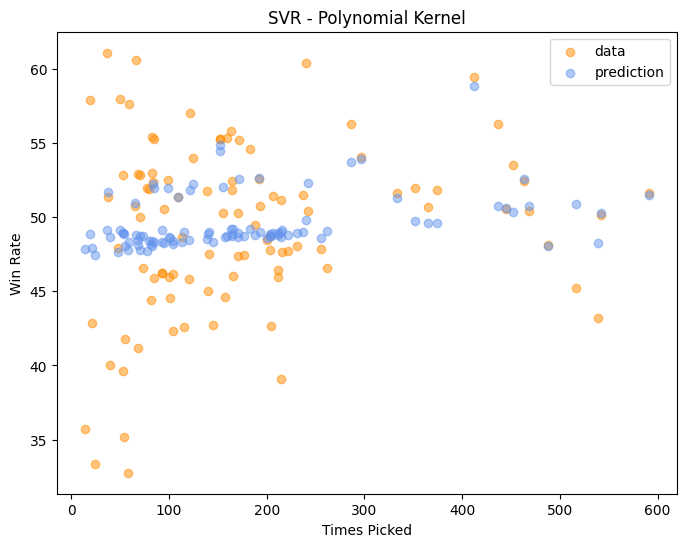

In [24]:
# Polynomial kernel
modelSVR_poly = SVR(kernel='poly', cache_size=1000)
modelSVR_poly.fit(X_train_scaled, y_train)
y_svr_poly_pred = modelSVR_poly.predict(X_test_scaled)
_ = Reg_Models_Evaluation_Metrics(modelSVR_poly, X_train_scaled, y_train, X_test_scaled, y_test, y_svr_poly_pred)

plt.figure(figsize=(8, 6))
plt.scatter(X_train['Times Picked'], y_train, color='darkorange', label='data', alpha=0.5)
plt.scatter(X_train['Times Picked'], modelSVR_poly.predict(X_train_scaled), color='cornflowerblue', label='prediction', alpha=0.5)
plt.xlabel('Times Picked')
plt.ylabel('Win Rate')
plt.legend()
plt.title('SVR - Polynomial Kernel')
plt.show()

RMSE:  8.1615
 R2: 0.0107
 Adjusted R2: -0.3966
 Cross Validated R2: -0.3102


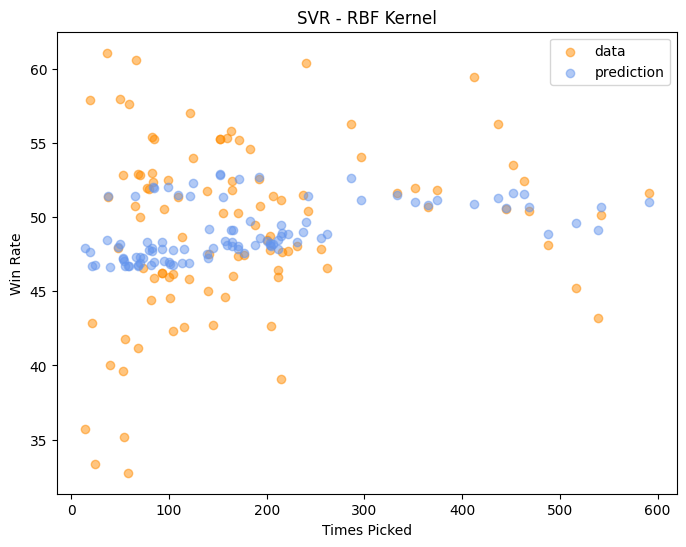

In [25]:
# RBF kernel
modelSVR_rbf = SVR(kernel='rbf', cache_size=1000)
modelSVR_rbf.fit(X_train_scaled, y_train)
y_svr_rbf_pred = modelSVR_rbf.predict(X_test_scaled)
_ = Reg_Models_Evaluation_Metrics(modelSVR_rbf, X_train_scaled, y_train, X_test_scaled, y_test, y_svr_rbf_pred)

plt.figure(figsize=(8, 6))
plt.scatter(X_train['Times Picked'], y_train, color='darkorange', label='data', alpha=0.5)
plt.scatter(X_train['Times Picked'], modelSVR_rbf.predict(X_train_scaled), color='cornflowerblue', label='prediction', alpha=0.5)
plt.xlabel('Times Picked')
plt.ylabel('Win Rate')
plt.legend()
plt.title('SVR - RBF Kernel')
plt.show()

## Elastic Net

RMSE:  7.4173
 R2: 0.1829
 Adjusted R2: -0.1535
 Cross Validated R2: 0.2864


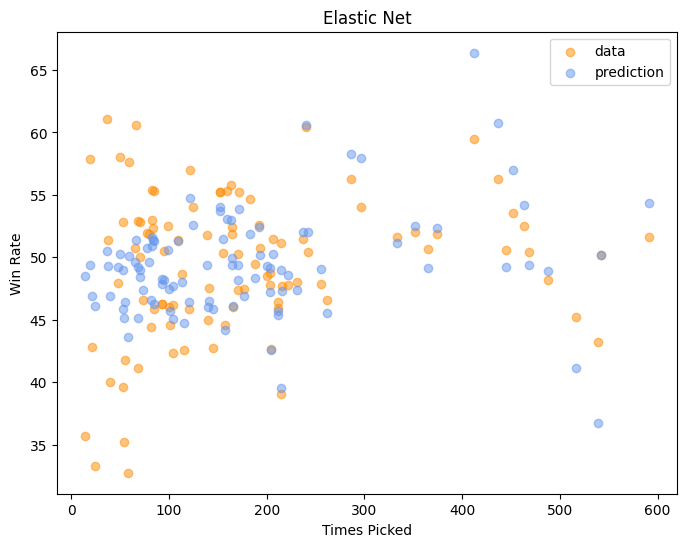

In [26]:
from sklearn.linear_model import ElasticNet

modelEN = ElasticNet(alpha=0.1, l1_ratio=0.8)
modelEN.fit(X_train, y_train)
y_en_pred = modelEN.predict(X_test)
_ = Reg_Models_Evaluation_Metrics(modelEN, X_train, y_train, X_test, y_test, y_en_pred)

plt.figure(figsize=(8, 6))
plt.scatter(X_train['Times Picked'], y_train, color='darkorange', label='data', alpha=0.5)
plt.scatter(X_train['Times Picked'], modelEN.predict(X_train), color='cornflowerblue', label='prediction', alpha=0.5)
plt.xlabel('Times Picked')
plt.ylabel('Win Rate')
plt.legend()
plt.title('Elastic Net')
plt.show()